GURU PRASAD N 24BAD029

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# CIFAR-10 class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# 2. Preprocess: Normalization 
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 3. Split dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# Flatten labels
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Testing data shape: {X_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1992s 12us/step
Training data shape: (40000, 32, 32, 3)
Validation data shape: (10000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def build_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        MaxPooling2D(pool_size=(2, 2)),
        
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        
        Conv2D(64, (3, 3), activation='relu'),
        
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax') 
    ])
    
    # Compile the model
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-24 15:47:24.313745: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8534 - loss: 0.4134 - val_accuracy: 0.6862 - val_loss: 1.0972
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8575 - loss: 0.4001 - val_accuracy: 0.6838 - val_loss: 1.1404
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8684 - loss: 0.3709 - val_accuracy: 0.6950 - val_loss: 1.0992
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.8753 - loss: 0.3482 - val_accuracy: 0.6916 - val_loss: 1.1845
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8803 - loss: 0.3319 - val_accuracy: 0.6952 - val_loss: 1.1704
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8871 - loss: 0.3147 - val_accuracy: 0.6841 - val_loss: 1.2470
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8974 - loss: 0.2904 - val_accuracy: 0.6784 - val_loss: 1.2952
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8

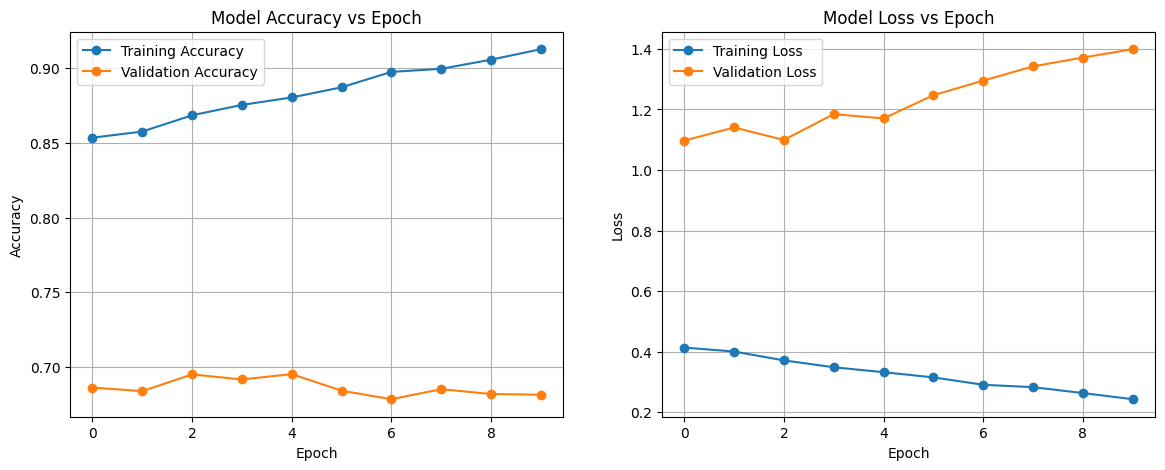

In [6]:
print("Starting training...")
history = cnn_model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=64
)

# Evaluate on Test Data
print("\nEvaluating on Test Set...")
test_loss, test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Final Testing Accuracy: {test_acc:.4f}")
print(f"Final Testing Loss: {test_loss:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
ax1.set_title('Model Accuracy vs Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Training Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='o')
ax2.set_title('Model Loss vs Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


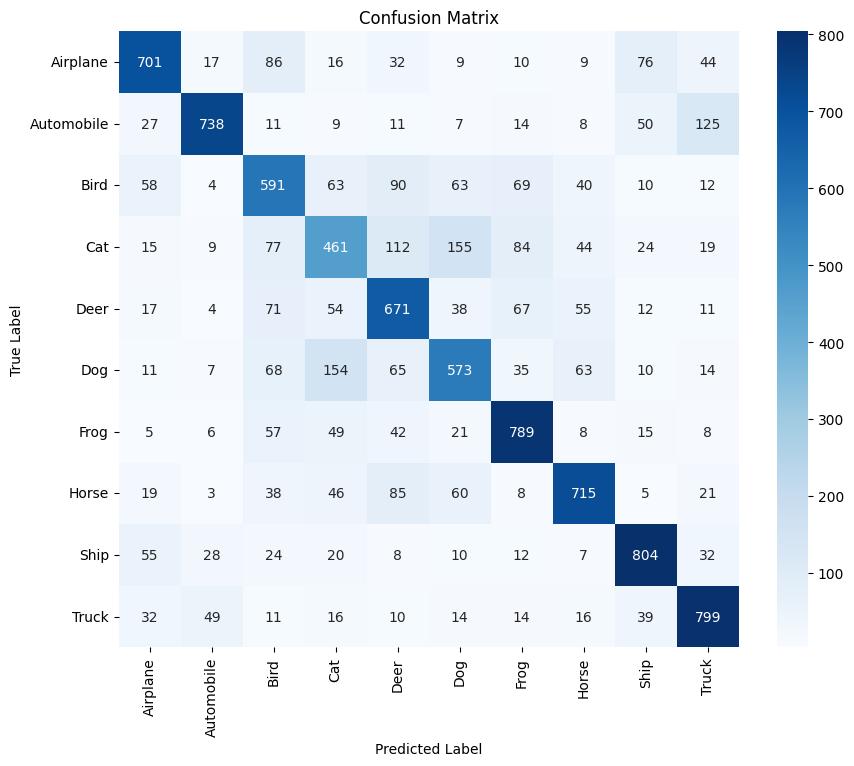


Correct Predictions:


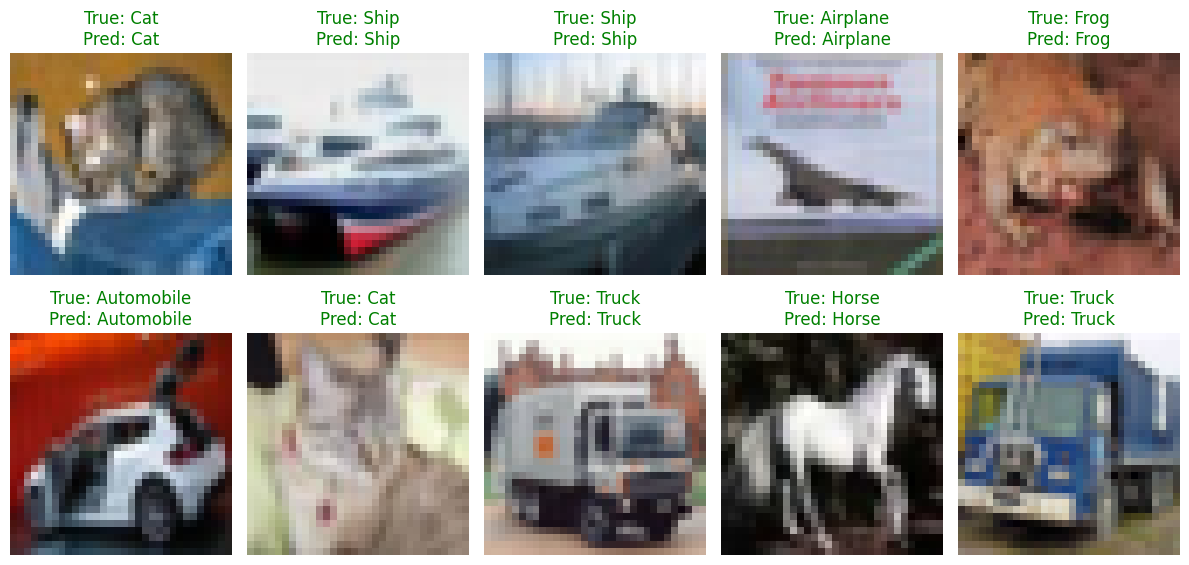


Misclassified Images:


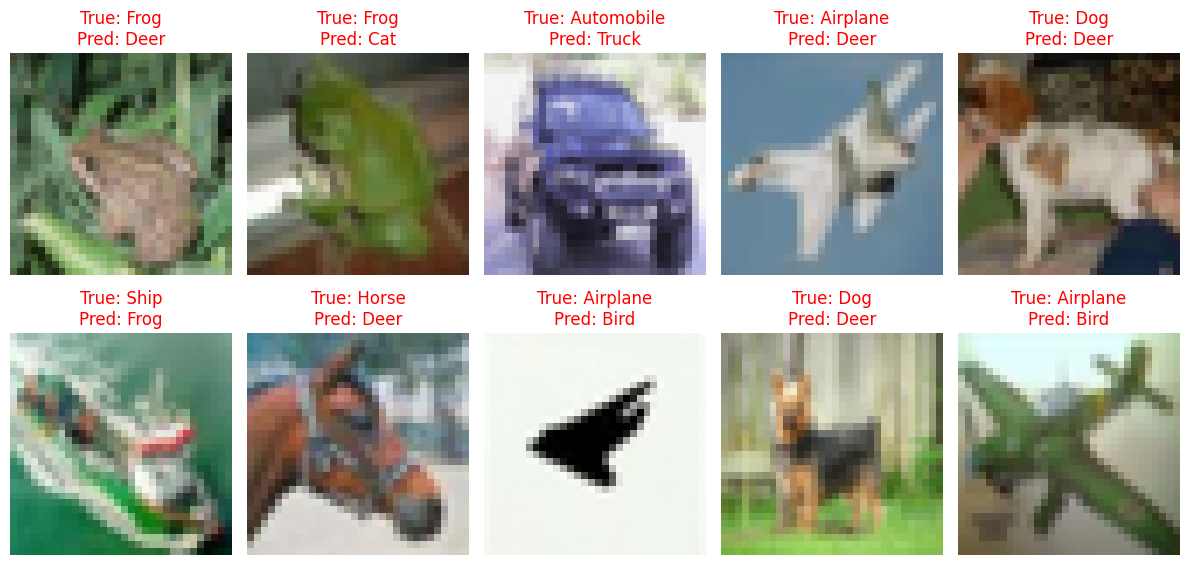

Nitheeswaran M 24BAD079


In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_probs = cnn_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nCorrect Predictions:")
correct_indices = np.where(y_pred == y_test)[0]
plt.figure(figsize=(12, 6))
for i in range(10):
    idx = correct_indices[i]
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", color='green')
    plt.axis('off')
plt.tight_layout()
plt.show()

print("\nMisclassified Images:")
misclassified_indices = np.where(y_pred != y_test)[0]
plt.figure(figsize=(12, 6))
for i in range(10):
    idx = misclassified_indices[i]
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", color='red')
    plt.axis('off')
plt.tight_layout()
plt.show()
print("Nitheeswaran M 24BAD079")

**Strengths of CNNs for Image Classification:**


* **Spatial Invariance:** Through pooling and weight sharing, CNNs can recognize a feature (like a wheel or an eye) regardless of where it appears in the image.
* **Automatic Feature Extraction:** Unlike traditional machine learning which requires manual feature engineering (e.g., HOG or SIFT), CNNs learn optimal feature filters automatically during the training process.
* **Hierarchical Learning:** Early layers learn basic patterns (edges, colors), while deeper layers learn complex objects (faces, cars), perfectly mimicking human visual processing.


**Limitations of CNNs:**


* **Data Hungry:** CNNs require massive amounts of labeled data to perform well without overfitting.
* **Lack of Spatial Relationship Context:** Standard CNNs do not inherently understand the relative positioning of features (e.g., a face with a nose above the eyes might still trigger as a "face"). This is what Capsule Networks try to solve.
* **Vulnerability to Adversarial Attacks:** Minor pixel perturbations invisible to the human eye can completely alter a CNN's prediction.
Hardware Constraints: Training deep architectures is computationally expensive and heavily relies on GPUs.